# CNN Keras

In [1]:
# Ignore  the warnings
import warnings
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

# data visualisation and manipulation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns
 
#configure
# sets matplotlib to inline and displays graphs below the corressponding cell.
%matplotlib inline  
style.use('fivethirtyeight')
sns.set(style='whitegrid',color_codes=True)

#model selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,roc_curve,roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

#preprocess.
from keras.preprocessing.image import ImageDataGenerator

#dl libraraies
from keras import backend as K
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam,SGD,Adagrad,Adadelta,RMSprop
from keras.utils import to_categorical

# specifically for cnn 
from keras.layers import Dropout, Flatten,Activation
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization
 
import tensorflow as tf
import random as rn

# specifically for manipulating zipped images and getting numpy arrays of pixel values of images.
import cv2                  
import numpy as np  
from tqdm import tqdm
import os                   
from random import shuffle  
from zipfile import ZipFile
from PIL import Image

<a id="content2"></a>
## 2 ) Preparing the Data

## 2.1) Making the functions to get the training, test, and validation set from the Images

## 3.3 ) Data Augmentation to prevent Overfitting

In [25]:
train_datagen = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
        'data/train',
        target_size=(150, 150),
        batch_size=32,
        class_mode='binary')
validation_generator = test_datagen.flow_from_directory(
        'data/validation',
        target_size=(150, 150),
        batch_size=32,
        class_mode='binary')
model.fit(
        train_generator,
        steps_per_epoch=2000,
        epochs=50,
        validation_data=validation_generator,
        validation_steps=800)

<a id="content3"></a>
## 3 ) Modelling

## 3.1 ) Building the ConvNet Model

In [ ]:
# modelling starts using a CNN.
model = Sequential()

model.add(Conv2D(filters = 32, kernel_size = (3, 3), padding = 'valid', activation ='relu', input_shape = (224,224,3)))
model.add(MaxPooling2D())

model.add(Conv2D(filters = 64, kernel_size = (3, 3), padding = 'valid', activation ='relu'))
model.add(MaxPooling2D())
 
model.add(Conv2D(filters = 128, kernel_size = (3, 3), padding = 'valid', activation ='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(filters = 128, kernel_size = (3, 3), padding = 'valid', activation ='relu'))
model.add(MaxPooling2D())
model.add(Dropout(0.2))

model.add(Flatten())

model.add(Dense(512, activation = 'relu'))

model.add(Dense(1, activation = "sigmoid"))

## 3.2 ) Using a LR Annealer

In [41]:
batch_size=32
epochs=50
from keras.callbacks import ReduceLROnPlateau
red_lr= ReduceLROnPlateau(monitor='val_f1', patience=4, verbose=1, factor=0.1)

In [44]:
datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        rotation_range=10,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range = 0.1, # Randomly zoom image 
        width_shift_range=0.2,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.2,  # randomly shift images vertically (fraction of total height)
        horizontal_flip=True,  # randomly flip images
        vertical_flip=False)  # randomly flip images

datagen.fit(X_train)

TypeError: __init__() got an unexpected keyword argument 'batch_size'

## 3.4 ) Compiling the Keras Model & Summary

In [39]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [40]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 220, 220, 32)      2432      
                                                                 
 max_pooling2d (MaxPooling2  (None, 110, 110, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 106, 106, 64)      51264     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 53, 53, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 49, 49, 128)       204928    
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 24, 24, 128)       0

## 3.5 ) Fitting on the Training set and making predcitons on the Validation set

In [42]:
History = model.fit_generator(datagen.flow(X_train, y_train, batch_size = batch_size),
                              epochs = epochs, validation_data = (X_val, y_val),
                              verbose = 1, steps_per_epoch=X_train.shape[0] // batch_size)
# model.fit(x_train,y_train,epochs=epochs,batch_size=batch_size,validation_data = (x_test,y_test))

Epoch 1/50
15/15 [==============================] - 104s 7s/step - loss: 1.3176 - accuracy: 0.7356 - val_loss: 0.5003 - val_accuracy: 0.8000
Epoch 2/50
15/15 [==============================] - 108s 7s/step - loss: 0.4793 - accuracy: 0.8189 - val_loss: 0.4817 - val_accuracy: 0.8000
Epoch 3/50
15/15 [==============================] - 105s 7s/step - loss: 0.4843 - accuracy: 0.8120 - val_loss: 0.4814 - val_accuracy: 0.8000
Epoch 4/50
15/15 [==============================] - 105s 7s/step - loss: 0.4738 - accuracy: 0.8152 - val_loss: 0.4736 - val_accuracy: 0.8000
Epoch 5/50
15/15 [==============================] - 104s 7s/step - loss: 0.4742 - accuracy: 0.8152 - val_loss: 0.4759 - val_accuracy: 0.8000
Epoch 6/50
15/15 [==============================] - 103s 7s/step - loss: 0.4704 - accuracy: 0.8157 - val_loss: 0.4727 - val_accuracy: 0.8000
Epoch 7/50
15/15 [==============================] - 103s 7s/step - loss: 0.4795 - accuracy: 0.8098 - val_loss: 0.4687 - val_accuracy: 0.8000
Epoch 8/50
15

KeyboardInterrupt: 

In [59]:
#save the model
from tensorflow.keras.models import save_model, load_model
save_model(model, 'model2_dropout.h5')

In [63]:
# load the model 
model2 = load_model('model2_dropout.h5')


<a id="content4"></a>
## 4 ) Evaluating the Model Performance

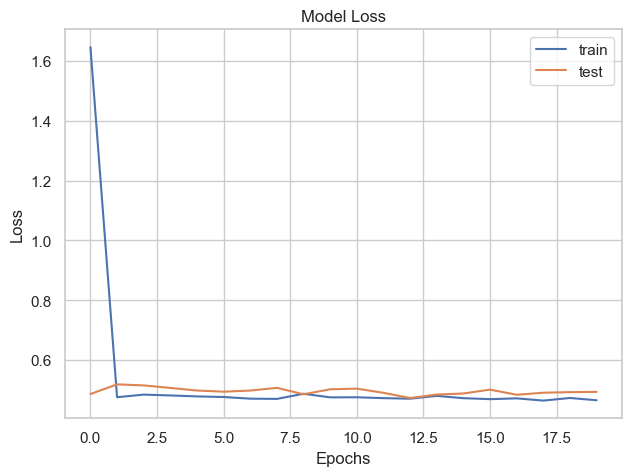

In [60]:
plt.plot(History.history['loss'])
plt.plot(History.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'test'])
plt.show()

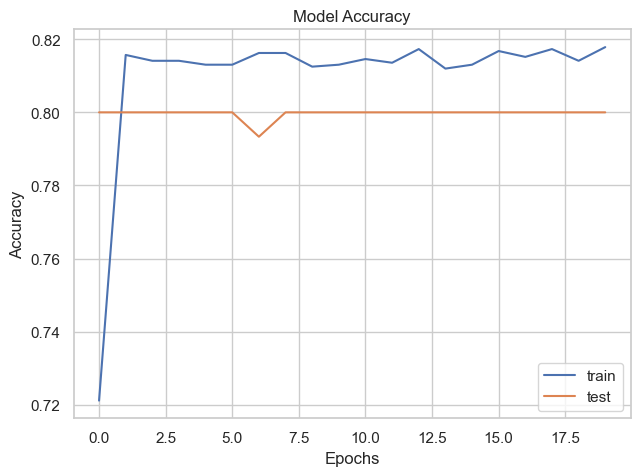

In [61]:
plt.plot(History.history['accuracy'])
plt.plot(History.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'test'])
plt.show()


<a id="content5"></a>
## 5 ) Visualizing Predictons on the Validation Set

In [66]:
X_test

array([], dtype=float64)

In [77]:
# getting predictions on val set.
pred=model.predict(X_test)
pred

19/19 [==============================] - 16s 810ms/step


array([[0.3319627 ],
       [0.3158947 ],
       [0.20830214],
       [0.30988878],
       [0.27246156],
       [0.3506726 ],
       [0.25626174],
       [0.24978174],
       [0.27598578],
       [0.2854526 ],
       [0.30448934],
       [0.2985565 ],
       [0.3146145 ],
       [0.33250785],
       [0.32258686],
       [0.32820407],
       [0.27179533],
       [0.30114752],
       [0.27150968],
       [0.30876857],
       [0.3403327 ],
       [0.346729  ],
       [0.26219776],
       [0.2714646 ],
       [0.33104575],
       [0.27939105],
       [0.223411  ],
       [0.28781915],
       [0.31636757],
       [0.2453928 ],
       [0.22296718],
       [0.27549353],
       [0.24686517],
       [0.30768037],
       [0.2650446 ],
       [0.30315748],
       [0.25863832],
       [0.3294922 ],
       [0.27278408],
       [0.31296808],
       [0.31601137],
       [0.2518208 ],
       [0.31522563],
       [0.3070711 ],
       [0.29261133],
       [0.26912647],
       [0.31203255],
       [0.349

In [78]:
pred_digits = (pred > 0.5).astype(int)
pred_digits

array([[0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
    

In [86]:
from sklearn.metrics import precision_score, recall_score, f1_score
precision = precision_score(y_test, pred_digits)

recall = recall_score(y_test, pred_digits)

f1 = f1_score(y_test, pred_digits)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Precision: 0.16666666666666666
Recall: 0.008547008547008548
F1 Score: 0.016260162601626018


In [ ]:

cm = confusion_matrix(y_test, pred_digits)

TP = cm[1, 1]
FP = cm[0, 1]
FN = cm[1, 0]
TN = cm[0, 0]

conf_matrix = np.array([[TP, FP], [FN, TN]])

# Define class labels (if not already defined)
class_names = ['Melanoma', 'Nevus & Keratosis']

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()


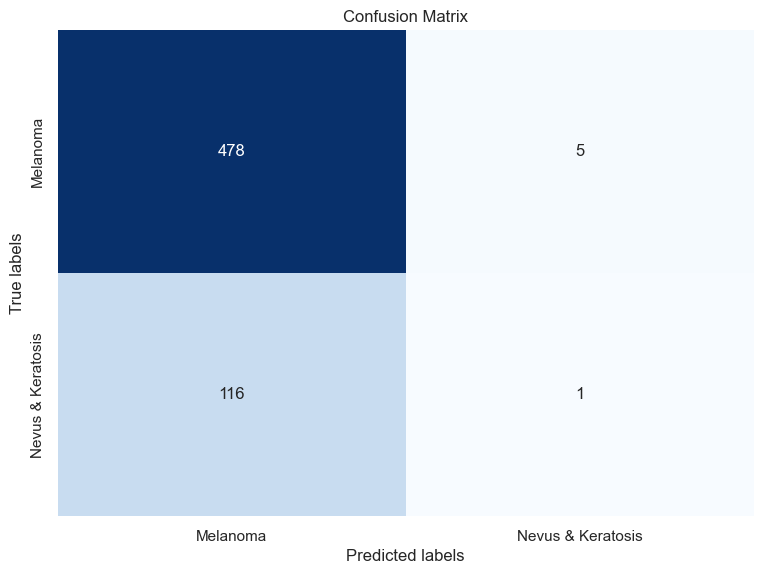

In [84]:
class_names = ['Melanoma','Nevus & Keratosis']
cm = confusion_matrix(y_test, pred_digits)
# Define class labels (if not already defined)
# class_names = ['Class 1', 'Class 2', ...]

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()


In [76]:
# now storing some properly as well as misclassified indexes'.
i=0
prop_class=[]
mis_class=[]

for i in range(len(y_test)):
    if(int(y_test[i])==int(pred_digits[i])):
        prop_class.append(i)
    if(len(prop_class)==8):
        break

i=0
for i in range(len(y_test)):
    if(not int(y_test[i])==int(pred_digits[i])):
        mis_class.append(i)
    if(len(mis_class)==8):
        break

#### CORRECTLY CLASSIFIED IMAGES

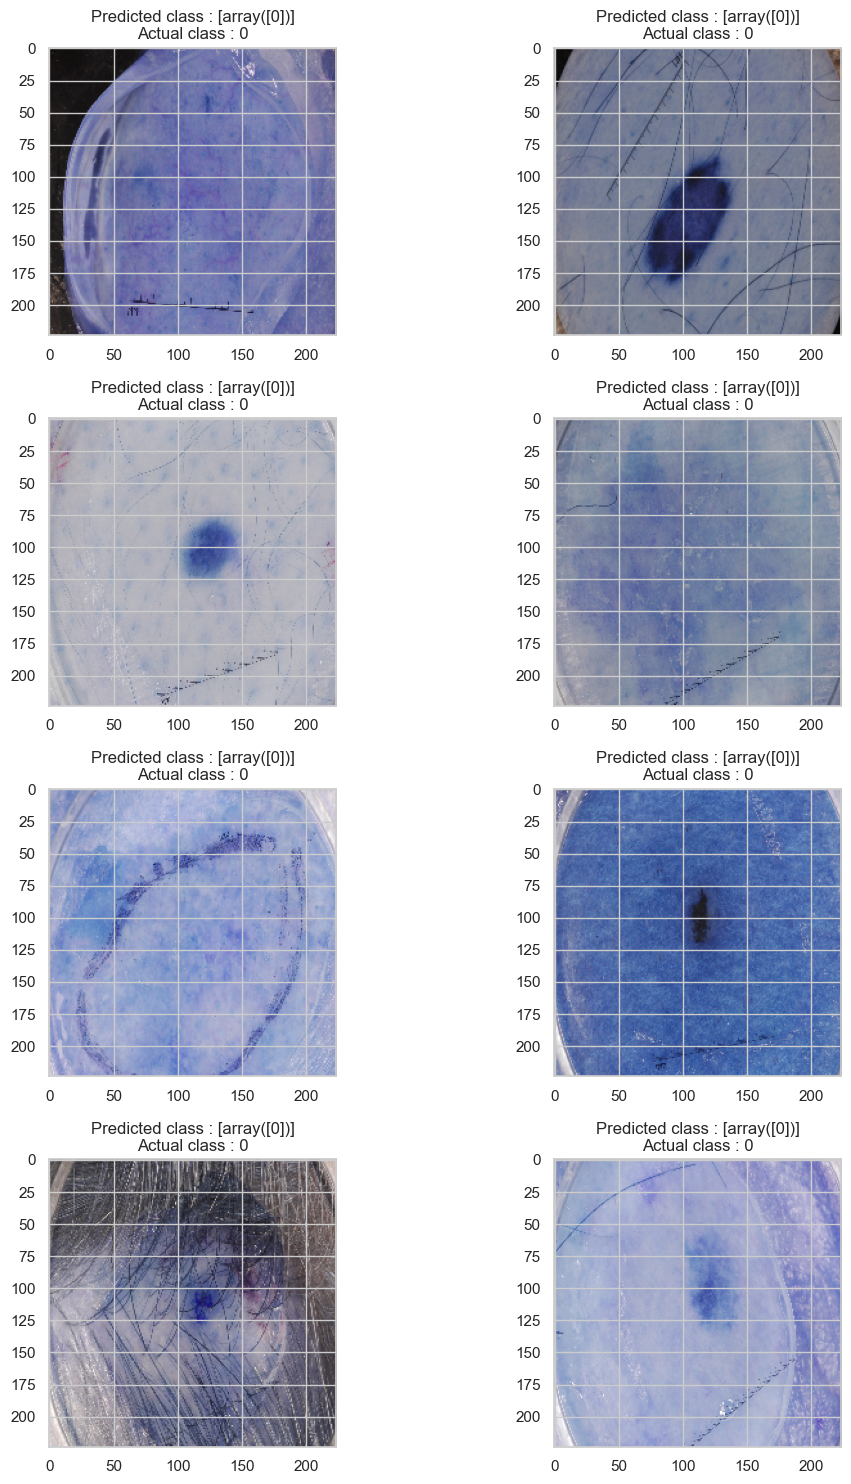

In [81]:
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

count=0
fig, ax=plt.subplots(4,2)
fig.set_size_inches(15,15)
for i in range (4):
    for j in range (2):
        if count < len(prop_class):
            idx = prop_class[count]
            ax[i,j].imshow(X_test[idx])
            ax[i,j].set_title(f"Predicted class : {int(pred_digits[idx])}\nActual class : {int(y_test[idx])}")
            plt.tight_layout()
            count+=1
        else:
            ax[i,j].axis('off')

#### MISCLASSIFIED IMAGES

IndexError: list index out of range

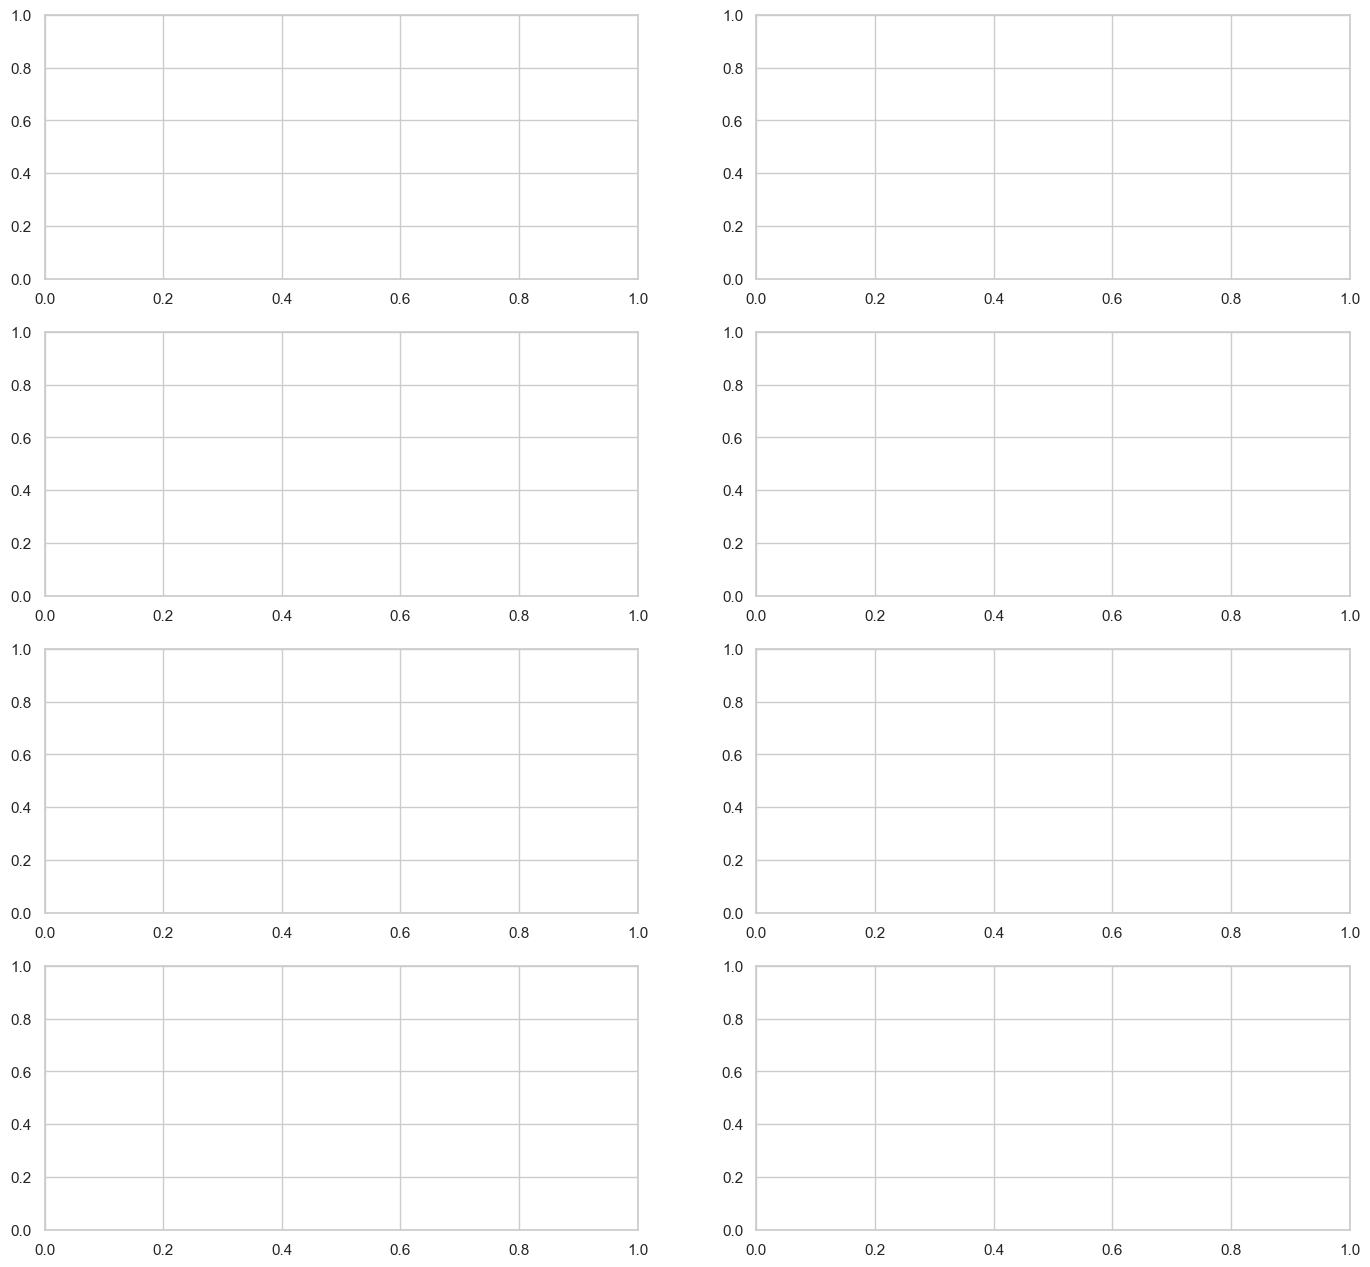

In [83]:
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

count=0
fig, ax=plt.subplots(4,2)
fig.set_size_inches(15,15)
for i in range (4):
    for j in range (2):
        if count < len(mis_class):
            idx = mis_class[count]
            ax[i,j].imshow(X_test[idx])
            ax[i,j].set_title(f"Predicted class : {int(pred_digits[idx])}\nActual class : {int(y_test[idx])}")
            plt.tight_layout()
            count+=1
        else:
            ax[i,j].axis('off')

In [84]:
len(X_test)

600

count